# Training & Evaluation EDA

Deep-dive analysis of all training runs in `LAND_AS/output/runs/`, including:
- Training loss and validation MAE curves per LOSO fold/seed
- Cosine annealing learning rate schedule visualization
- Early stopping behavior across folds
- Cross-run comparison of hyperparameters and evaluation metrics
- Observed vs predicted scatter plots and error analysis
- Per-station and seasonal error breakdowns
- Ensemble uncertainty analysis
- Q-Q plots of predicted vs observed

**Pipeline design:** train and test are strictly spatiotemporally disjoint:
- **Train**: 21 stations, 1980–2016
- **Test**: 5 stations (`aasu_UH`, `afono_UH`, `aunuu_UH`, `poloa_UH`, `vaipito_UH`), 2017–2024
- **Tuning**: 3-fold spatial CV over the 21 train stations
- **Final training**: full LOSO CV over the 21 train stations, multiple seeds
- **Evaluation**: ensemble of all LOSO models on the held-out test set

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize
from pathlib import Path
import json
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'figure.facecolor': 'white',
})

RUNS_DIR = Path('../output/runs')
DATASET_PATH = Path('../data/weekly_dataset.npz')

# Discover all runs
run_dirs = sorted([d for d in RUNS_DIR.iterdir() if d.is_dir() and (d / 'hyperparameters.json').exists()])
run_names = [d.name for d in run_dirs]
print(f'Found {len(run_dirs)} training runs: {run_names}')

Found 1 training runs: ['weekly_land']


In [2]:
# Load all run data
runs = {}
for run_dir in run_dirs:
    name = run_dir.name
    run = {
        'hp': json.loads((run_dir / 'hyperparameters.json').read_text()),
        'histories': [],
        'fold_seed_labels': [],
        'held_out_stations': [],
        'eval': {},
        'predictions': {},
    }
    
    # Load normalization and split if available
    if (run_dir / 'normalization.json').exists():
        run['normalization'] = json.loads((run_dir / 'normalization.json').read_text())
    if (run_dir / 'split.json').exists():
        run['split'] = json.loads((run_dir / 'split.json').read_text())
    
    # Load training histories
    for hist_path in sorted(run_dir.glob('fold_*/seed_*_history.json')):
        history = json.loads(hist_path.read_text())
        run['histories'].append(history)
        fold = hist_path.parent.name
        seed = hist_path.stem.replace('_history', '')
        run['fold_seed_labels'].append(f'{fold}/{seed}')
        run['held_out_stations'].append(history.get('held_out_station', 'unknown'))
    
    # Load evaluation metrics
    eval_dir = run_dir / 'evaluation'
    if eval_dir.exists():
        for metrics_path in eval_dir.glob('*_metrics.json'):
            split_name = metrics_path.stem.replace('_metrics', '')
            run['eval'][split_name] = json.loads(metrics_path.read_text())
        for pred_path in eval_dir.glob('*_predictions.npz'):
            split_name = pred_path.stem.replace('_predictions', '')
            run['predictions'][split_name] = dict(np.load(pred_path, allow_pickle=True))
    
    runs[name] = run

# Summary
for name, run in runs.items():
    n_hist = len(run['histories'])
    n_eval = len(run['eval'])
    lr = run['hp'].get('learning_rate', 'N/A')
    eval_splits_found = list(run['eval'].keys())
    unique_folds = len(set(l.split('/')[0] for l in run['fold_seed_labels']))
    unique_seeds = len(set(l.split('/')[1] for l in run['fold_seed_labels'])) if run['fold_seed_labels'] else 0
    print(f'{name}: lr={lr:.2e}, {unique_folds} folds x {unique_seeds} seeds = {n_hist} models, eval splits: {eval_splits_found}')

weekly_land: lr=1.19e-04, 23 folds x 3 seeds = 69 models, eval splits: ['test']


---
## 1. Hyperparameter Comparison Across Runs

In [3]:
# Compare hyperparameters across runs
hp_keys = list(runs[run_names[0]]['hp'].keys())
print(f'Hyperparameters: {hp_keys}\n')

# Find which parameters differ
differing = []
same = []
for key in hp_keys:
    values = [runs[name]['hp'].get(key) for name in run_names]
    if len(set(str(v) for v in values)) > 1:
        differing.append(key)
    else:
        same.append(key)

print('Parameters that DIFFER across runs:')
for key in differing:
    values = {name: runs[name]['hp'].get(key) for name in run_names}
    print(f'  {key}: {values}')

print(f'\nParameters that are SAME: {same}')

Hyperparameters: ['climate_units', 'dem_units', 'month_units', 'hidden_units', 'dropout', 'batch_size', 'learning_rate', 'weight_decay']

Parameters that DIFFER across runs:

Parameters that are SAME: ['climate_units', 'dem_units', 'month_units', 'hidden_units', 'dropout', 'batch_size', 'learning_rate', 'weight_decay']


---
## 2. Training Curves

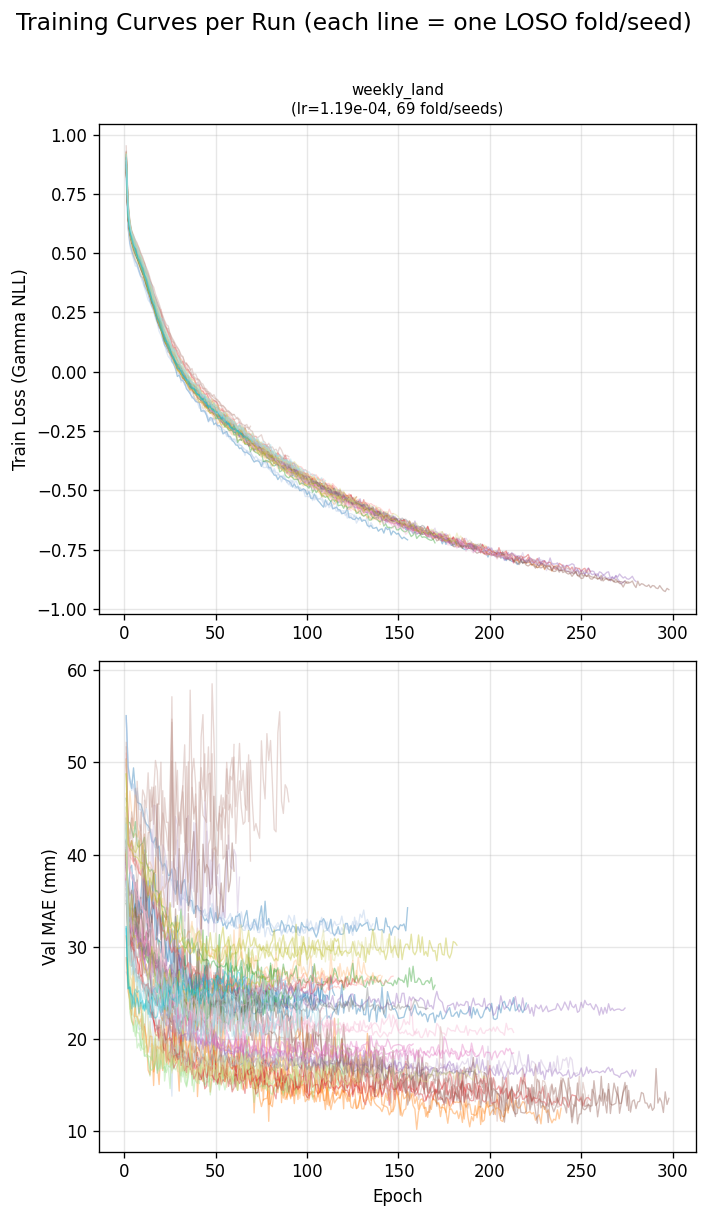

In [4]:
# Training loss and val MAE curves per run (all folds/seeds overlaid)
n_runs = len(run_names)
fig, axes = plt.subplots(2, n_runs, figsize=(6 * n_runs, 10))
if n_runs == 1:
    axes = axes.reshape(-1, 1)

for ri, name in enumerate(run_names):
    run = runs[name]
    lr = run['hp'].get('learning_rate', 0)
    n_histories = len(run['histories'])
    
    for hi, (history, label) in enumerate(zip(run['histories'], run['fold_seed_labels'])):
        epochs = range(1, len(history['train_loss']) + 1)
        color = plt.cm.tab20(hi / max(n_histories, 1))
        
        axes[0, ri].plot(epochs, history['train_loss'], alpha=0.4, lw=0.8, color=color)
        axes[1, ri].plot(epochs, history['val_mae_mm'], alpha=0.4, lw=0.8, color=color)
    
    axes[0, ri].set_title(f'{name}\n(lr={lr:.2e}, {n_histories} fold/seeds)', fontsize=9)
    axes[0, ri].set_ylabel('Train Loss (Gamma NLL)')
    axes[0, ri].grid(alpha=0.3)
    
    axes[1, ri].set_xlabel('Epoch')
    axes[1, ri].set_ylabel('Val MAE (mm)')
    axes[1, ri].grid(alpha=0.3)

fig.suptitle('Training Curves per Run (each line = one LOSO fold/seed)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

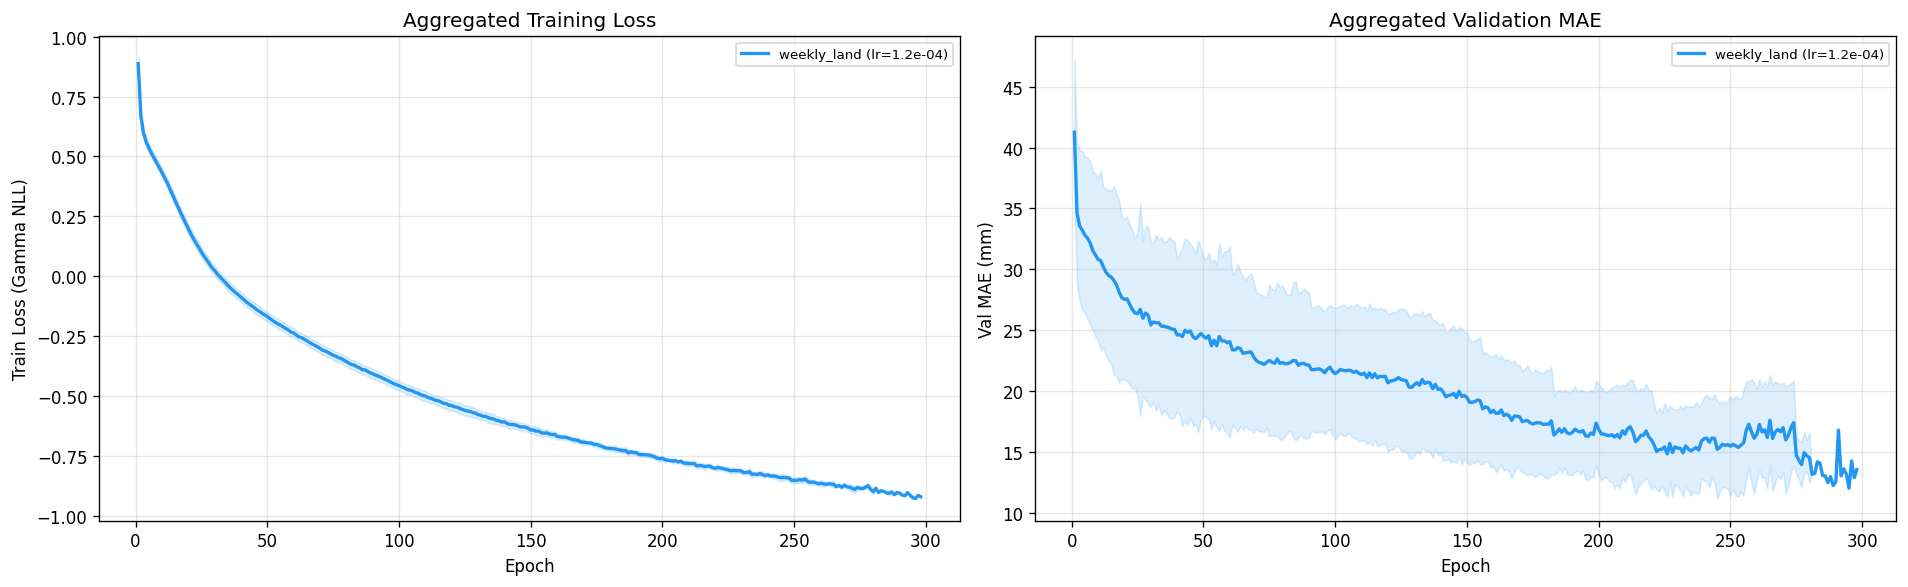

In [5]:
# Aggregate training curves: mean +/- std across seeds within each run
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
run_plot_colors = ['#2196F3', '#4CAF50', '#F44336', '#FF9800', '#9C27B0']

for ri, name in enumerate(run_names):
    run = runs[name]
    lr = run['hp'].get('learning_rate', 0)
    color = run_plot_colors[ri % len(run_plot_colors)]
    
    # Pad histories to same length
    max_len = max(len(h['val_mae_mm']) for h in run['histories'])
    all_mae = np.full((len(run['histories']), max_len), np.nan)
    all_loss = np.full((len(run['histories']), max_len), np.nan)
    for hi, h in enumerate(run['histories']):
        all_mae[hi, :len(h['val_mae_mm'])] = h['val_mae_mm']
        all_loss[hi, :len(h['train_loss'])] = h['train_loss']
    
    epochs = np.arange(1, max_len + 1)
    mean_mae = np.nanmean(all_mae, axis=0)
    std_mae = np.nanstd(all_mae, axis=0)
    mean_loss = np.nanmean(all_loss, axis=0)
    std_loss = np.nanstd(all_loss, axis=0)
    
    axes[0].plot(epochs, mean_loss, color=color, lw=2, label=f'{name} (lr={lr:.1e})')
    axes[0].fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, color=color, alpha=0.15)
    axes[1].plot(epochs, mean_mae, color=color, lw=2, label=f'{name} (lr={lr:.1e})')
    axes[1].fill_between(epochs, mean_mae - std_mae, mean_mae + std_mae, color=color, alpha=0.15)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Train Loss (Gamma NLL)')
axes[0].set_title('Aggregated Training Loss')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val MAE (mm)')
axes[1].set_title('Aggregated Validation MAE')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 2b. Cosine Annealing Learning Rate Schedule

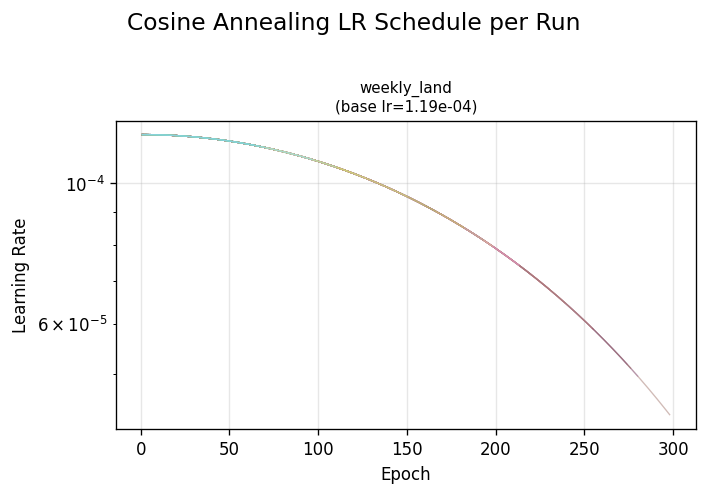

In [6]:
# Cosine annealing LR schedule visualization
# Check if any run has learning_rate history
has_lr_history = any(
    'learning_rate' in h for run in runs.values() for h in run['histories']
)

if has_lr_history:
    fig, axes = plt.subplots(1, len(run_names), figsize=(6 * len(run_names), 4))
    if len(run_names) == 1:
        axes = [axes]
    
    for ri, name in enumerate(run_names):
        run = runs[name]
        ax = axes[ri]
        for hi, history in enumerate(run['histories']):
            if 'learning_rate' in history:
                epochs = range(1, len(history['learning_rate']) + 1)
                ax.plot(epochs, history['learning_rate'], alpha=0.4, lw=0.8,
                        color=plt.cm.tab20(hi / max(len(run['histories']), 1)))
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Learning Rate')
        ax.set_title(f'{name}\n(base lr={run["hp"].get("learning_rate", 0):.2e})', fontsize=9)
        ax.set_yscale('log')
        ax.grid(alpha=0.3)
    
    fig.suptitle('Cosine Annealing LR Schedule per Run', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No learning_rate history found in training histories (older runs used fixed LR).')

---
## 3. Early Stopping & Convergence

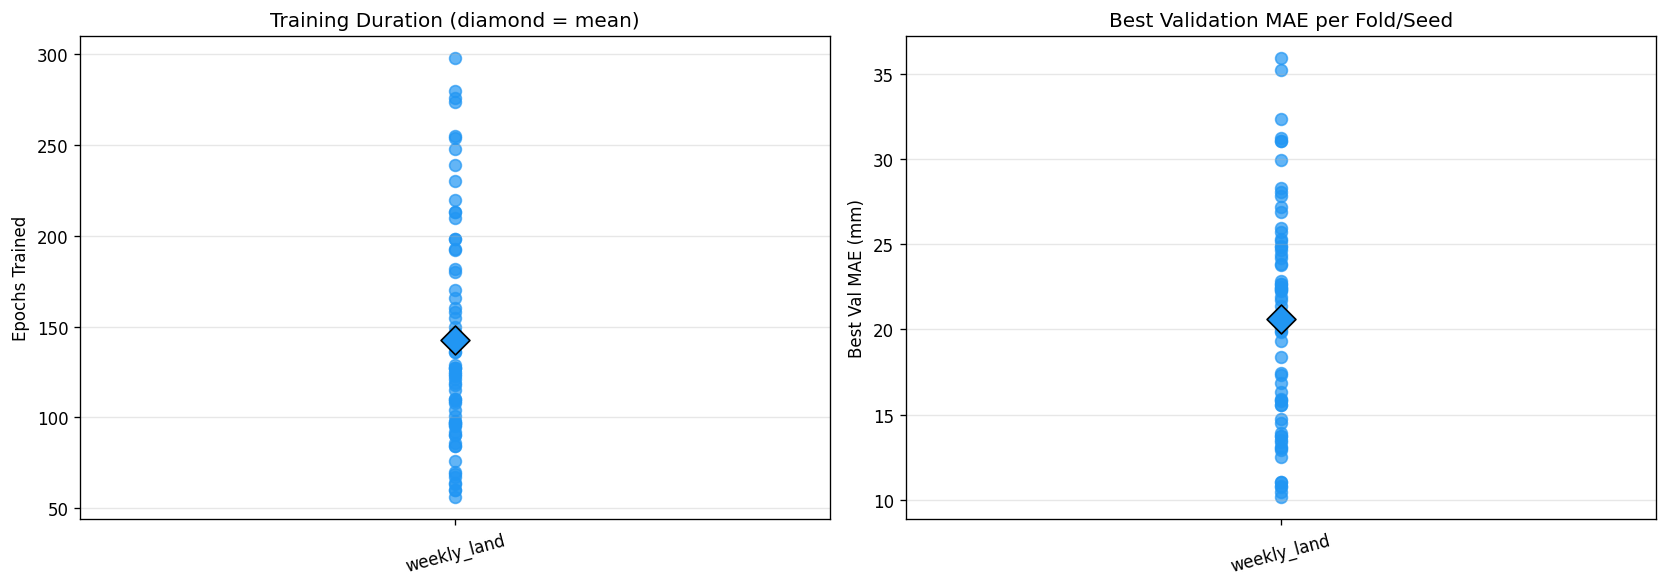

Run                        Mean Epochs   Std Epochs   Mean BestMAE  Std BestMAE
--------------------------------------------------------------------------------
weekly_land                      142.7         62.0          20.62         6.37


In [7]:
# Early stopping analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ri, name in enumerate(run_names):
    run = runs[name]
    color = run_plot_colors[ri % len(run_plot_colors)]
    n_epochs_list = [len(h['train_loss']) for h in run['histories']]
    best_mae_list = [h['best_val_mae_mm'] for h in run['histories']]
    
    # Epochs trained
    axes[0].scatter([name] * len(n_epochs_list), n_epochs_list, color=color, s=50, alpha=0.7)
    axes[0].scatter(name, np.mean(n_epochs_list), color=color, s=150, marker='D', edgecolor='black', zorder=5)
    
    # Best val MAE
    axes[1].scatter([name] * len(best_mae_list), best_mae_list, color=color, s=50, alpha=0.7)
    axes[1].scatter(name, np.mean(best_mae_list), color=color, s=150, marker='D', edgecolor='black', zorder=5)

axes[0].set_ylabel('Epochs Trained')
axes[0].set_title('Training Duration (diamond = mean)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

axes[1].set_ylabel('Best Val MAE (mm)')
axes[1].set_title('Best Validation MAE per Fold/Seed')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics table
print(f'{"Run":<25} {"Mean Epochs":>12} {"Std Epochs":>12} {"Mean BestMAE":>14} {"Std BestMAE":>12}')
print('-' * 80)
for name in run_names:
    run = runs[name]
    n_ep = [len(h['train_loss']) for h in run['histories']]
    best_m = [h['best_val_mae_mm'] for h in run['histories']]
    print(f'{name:<25} {np.mean(n_ep):>12.1f} {np.std(n_ep):>12.1f} {np.mean(best_m):>14.2f} {np.std(best_m):>12.2f}')

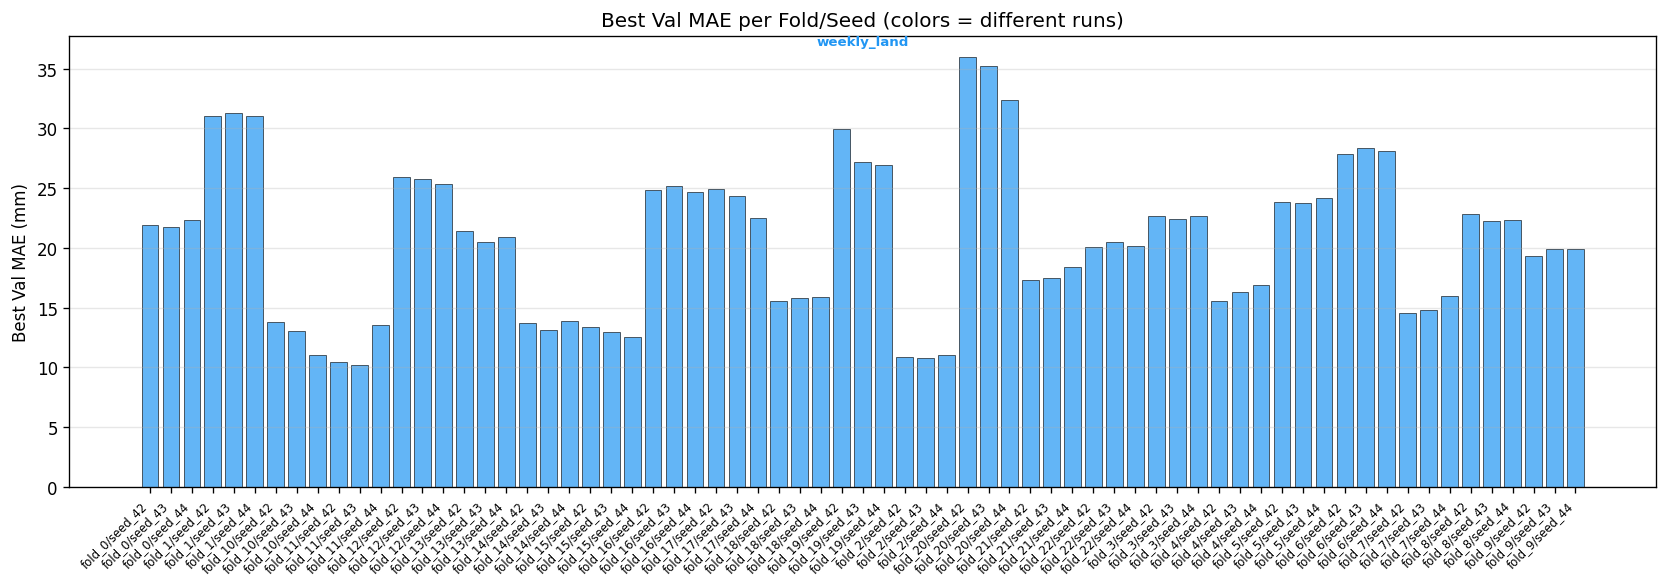

In [8]:
# Best MAE per fold (to see spatial vs temporal fold differences)
fig, ax = plt.subplots(figsize=(14, 5))
x_pos = 0
tick_positions = []
tick_labels = []

for ri, name in enumerate(run_names):
    run = runs[name]
    color = run_plot_colors[ri % len(run_plot_colors)]
    
    for hi, (history, label) in enumerate(zip(run['histories'], run['fold_seed_labels'])):
        ax.bar(x_pos, history['best_val_mae_mm'], color=color, alpha=0.7, edgecolor='black', lw=0.5)
        tick_positions.append(x_pos)
        tick_labels.append(f'{label}')
        x_pos += 1
    x_pos += 1  # gap between runs

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Best Val MAE (mm)')
ax.set_title('Best Val MAE per Fold/Seed (colors = different runs)')
ax.grid(axis='y', alpha=0.3)

# Add run name annotations
pos = 0
for ri, name in enumerate(run_names):
    n = len(runs[name]['histories'])
    mid = pos + n / 2 - 0.5
    ax.text(mid, ax.get_ylim()[1] * 0.98, name, ha='center', fontsize=8, fontweight='bold',
            color=run_plot_colors[ri % len(run_plot_colors)])
    pos += n + 1

plt.tight_layout()
plt.show()

---
## 4. Evaluation Metrics Comparison

In [9]:
# Cross-run evaluation metrics comparison
# Dynamically detect available eval splits (new runs use 'test', old runs use 'test_temporal'/'test_spatial')
all_eval_splits = set()
for name in run_names:
    all_eval_splits.update(runs[name]['eval'].keys())
eval_splits = sorted(all_eval_splits)
metrics_list = ['mae', 'rmse', 'r2', 'bias', 'spearman_r']

print(f'Available evaluation splits: {eval_splits}\n')

# Gather data
eval_data = {}
for name in run_names:
    eval_data[name] = {}
    for split in eval_splits:
        if split in runs[name]['eval']:
            eval_data[name][split] = runs[name]['eval'][split]

# Print table
for split in eval_splits:
    print(f'\n=== {split.upper()} ===')
    print(f'{"Run":<25}', end='')
    for m in metrics_list:
        print(f'{m:>12}', end='')
    print()
    print('-' * (25 + 12 * len(metrics_list)))
    for name in run_names:
        if split in eval_data[name]:
            print(f'{name:<25}', end='')
            for m in metrics_list:
                val = eval_data[name][split].get(m, float('nan'))
                print(f'{val:>12.3f}', end='')
            print()

Available evaluation splits: ['test']


=== TEST ===
Run                               mae        rmse          r2        bias  spearman_r
-------------------------------------------------------------------------------------
weekly_land                    24.074      37.654       0.668      -1.941       0.858


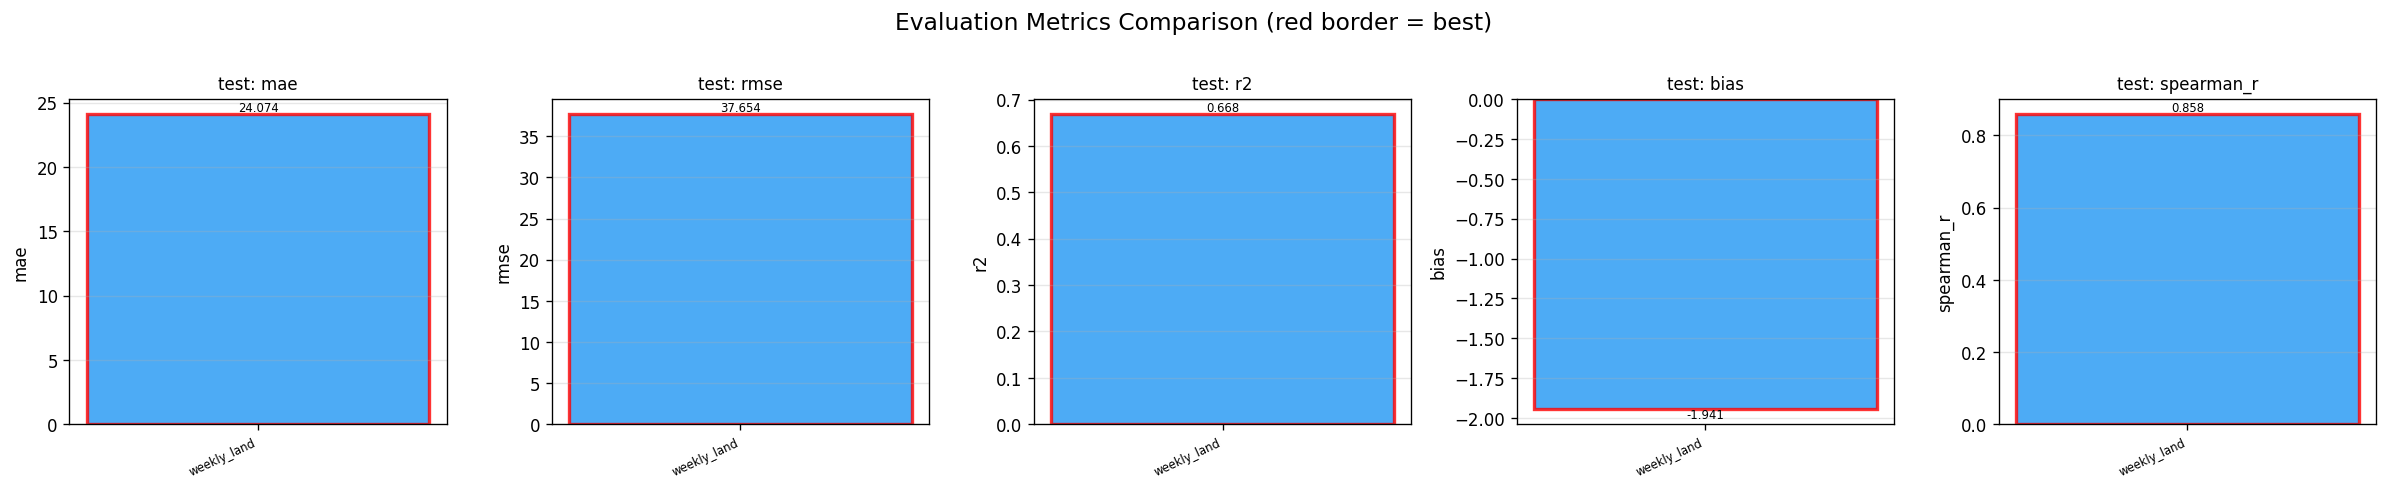

In [10]:
# Bar chart comparison of key metrics
metrics_to_plot = ['mae', 'rmse', 'r2', 'bias', 'spearman_r']

fig, axes = plt.subplots(len(eval_splits), len(metrics_to_plot),
                         figsize=(4 * len(metrics_to_plot), 4 * max(len(eval_splits), 1)),
                         squeeze=False)

for si, split in enumerate(eval_splits):
    for mi, metric in enumerate(metrics_to_plot):
        ax = axes[si, mi]
        vals = []
        labels = []
        colors = []
        for ri, name in enumerate(run_names):
            if split in eval_data[name]:
                vals.append(eval_data[name][split].get(metric, 0))
                labels.append(name)
                colors.append(run_plot_colors[ri % len(run_plot_colors)])
        
        if not vals:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            continue
        
        bars = ax.bar(range(len(vals)), vals, color=colors, alpha=0.8, edgecolor='black', lw=0.5)
        ax.set_xticks(range(len(vals)))
        ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=7)
        ax.set_ylabel(metric)
        ax.set_title(f'{split}: {metric}', fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        
        # Annotate values
        for j, v in enumerate(vals):
            ax.text(j, v + (0.01 * abs(v) if v >= 0 else -0.03 * abs(v)),
                    f'{v:.3f}', ha='center', fontsize=7)
        
        # Highlight best
        if metric in ('r2', 'spearman_r'):
            best = np.argmax(vals)
        elif metric == 'bias':
            best = np.argmin(np.abs(vals))
        else:
            best = np.argmin(vals)
        bars[best].set_edgecolor('red')
        bars[best].set_linewidth(2)

plt.suptitle('Evaluation Metrics Comparison (red border = best)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

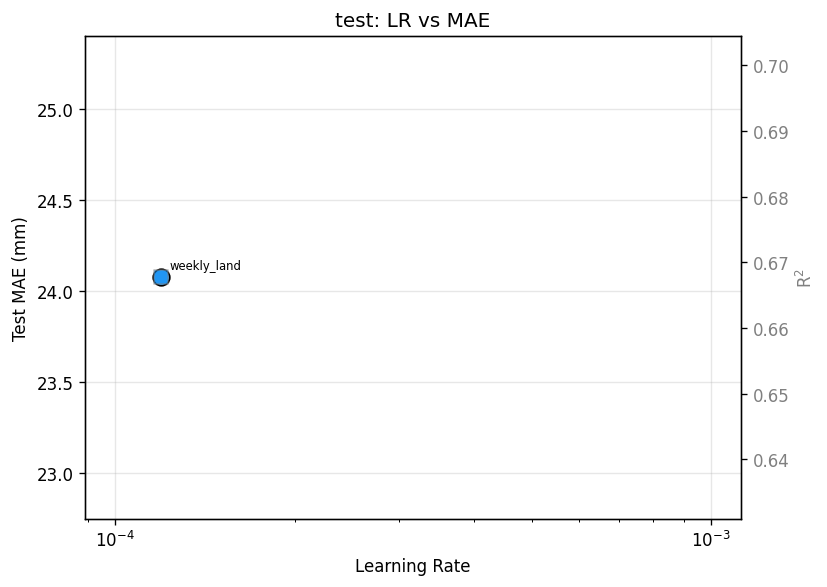

In [11]:
# Learning rate vs test MAE (ablation summary)
n_plots = len(eval_splits)
fig, axes = plt.subplots(1, max(n_plots, 1), figsize=(7 * max(n_plots, 1), 5), squeeze=False)

for si, split in enumerate(eval_splits):
    ax = axes[0, si]
    lrs = []
    maes = []
    r2s = []
    labels = []
    for name in run_names:
        if split in eval_data[name]:
            lrs.append(runs[name]['hp']['learning_rate'])
            maes.append(eval_data[name][split]['mae'])
            r2s.append(eval_data[name][split]['r2'])
            labels.append(name)
    
    if not lrs:
        continue
    ax.scatter(lrs, maes, s=100, c=run_plot_colors[:len(lrs)], edgecolor='black', zorder=5)
    for i, label in enumerate(labels):
        ax.annotate(label, (lrs[i], maes[i]), fontsize=7,
                      xytext=(5, 5), textcoords='offset points')
    ax.set_xscale('log')
    ax.set_xlabel('Learning Rate')
    ax.set_ylabel('Test MAE (mm)')
    ax.set_title(f'{split}: LR vs MAE')
    ax.grid(alpha=0.3)
    
    # Add R2 on secondary axis
    ax2 = ax.twinx()
    ax2.scatter(lrs, r2s, s=80, marker='s', c=run_plot_colors[:len(lrs)], edgecolor='gray', alpha=0.5)
    ax2.set_ylabel('R$^2$', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()

---
## 5. Observed vs Predicted Analysis

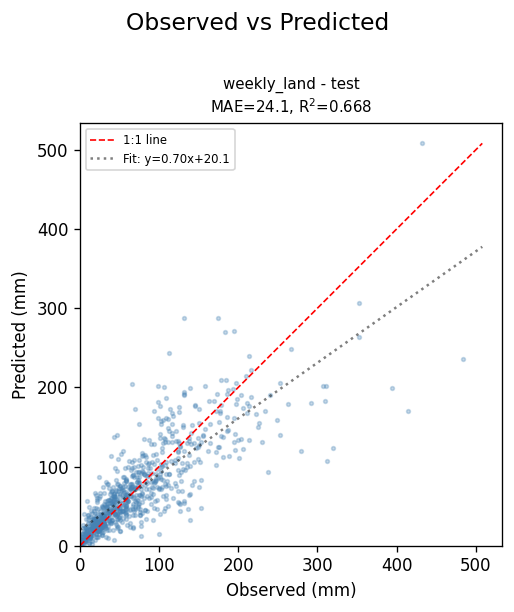

In [12]:
# Scatter plots: observed vs predicted for each run/split
runs_with_preds = [n for n in run_names if runs[n]['predictions']]

fig, axes = plt.subplots(len(eval_splits), len(runs_with_preds),
                         figsize=(5 * len(runs_with_preds), 5 * max(len(eval_splits), 1)),
                         squeeze=False)

for si, split in enumerate(eval_splits):
    for ri, name in enumerate(runs_with_preds):
        ax = axes[si, ri]
        preds = runs[name]['predictions'].get(split)
        if preds is None:
            ax.text(0.5, 0.5, 'No predictions', ha='center', va='center', transform=ax.transAxes)
            continue
        
        obs = preds['observed']
        pred = preds['predicted']
        
        ax.scatter(obs, pred, s=5, alpha=0.3, color='steelblue')
        max_val = max(obs.max(), pred.max())
        ax.plot([0, max_val], [0, max_val], 'r--', lw=1, label='1:1 line')
        
        # Regression line
        z = np.polyfit(obs, pred, 1)
        x_fit = np.linspace(0, max_val, 100)
        ax.plot(x_fit, np.polyval(z, x_fit), 'k:', alpha=0.5, label=f'Fit: y={z[0]:.2f}x+{z[1]:.1f}')
        
        metrics = runs[name]['eval'].get(split, {})
        ax.set_xlabel('Observed (mm)')
        ax.set_ylabel('Predicted (mm)')
        ax.set_title(f'{name} - {split}\nMAE={metrics.get("mae",0):.1f}, R$^2$={metrics.get("r2",0):.3f}', fontsize=9)
        ax.legend(fontsize=7)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlim(0, max_val * 1.05)
        ax.set_ylim(0, max_val * 1.05)

plt.suptitle('Observed vs Predicted', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

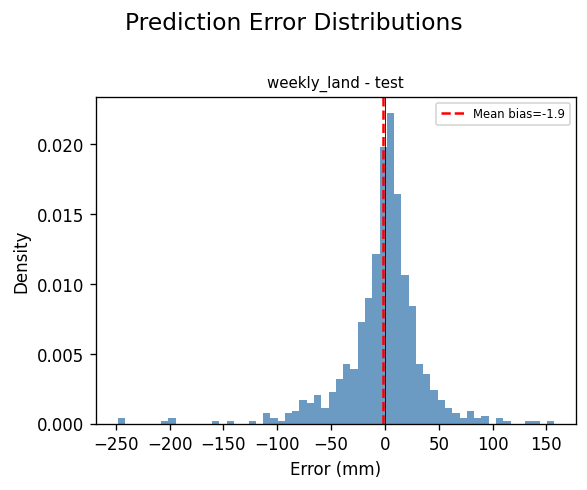

In [13]:
# Error distribution (predicted - observed)
fig, axes = plt.subplots(len(eval_splits), len(runs_with_preds),
                         figsize=(5 * len(runs_with_preds), 4 * max(len(eval_splits), 1)),
                         squeeze=False)

for si, split in enumerate(eval_splits):
    for ri, name in enumerate(runs_with_preds):
        ax = axes[si, ri]
        preds = runs[name]['predictions'].get(split)
        if preds is None:
            continue
        
        errors = preds['predicted'] - preds['observed']
        ax.hist(errors, bins=60, color='steelblue', alpha=0.8, edgecolor='none', density=True)
        ax.axvline(0, color='black', ls='-', lw=0.5)
        ax.axvline(errors.mean(), color='red', ls='--', label=f'Mean bias={errors.mean():.1f}')
        ax.set_xlabel('Error (mm)')
        ax.set_ylabel('Density')
        ax.set_title(f'{name} - {split}', fontsize=9)
        ax.legend(fontsize=7)

plt.suptitle('Prediction Error Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Ensemble Uncertainty Analysis

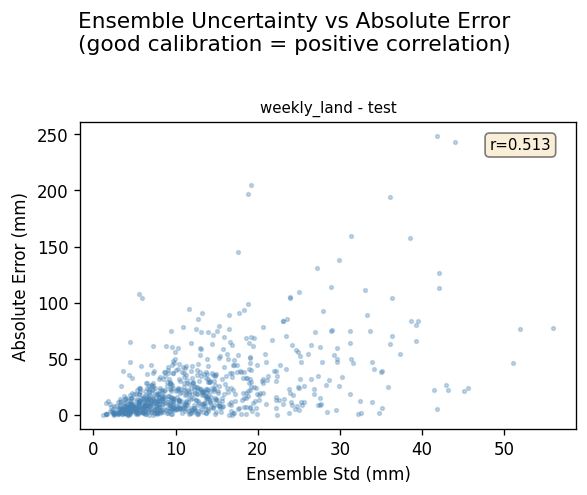

In [14]:
# Uncertainty (ensemble std) analysis
fig, axes = plt.subplots(len(eval_splits), len(runs_with_preds),
                         figsize=(5 * len(runs_with_preds), 4 * max(len(eval_splits), 1)),
                         squeeze=False)

for si, split in enumerate(eval_splits):
    for ri, name in enumerate(runs_with_preds):
        ax = axes[si, ri]
        preds = runs[name]['predictions'].get(split)
        if preds is None:
            continue
        
        unc = preds.get('uncertainty', np.zeros_like(preds['predicted']))
        abs_errors = np.abs(preds['predicted'] - preds['observed'])
        
        ax.scatter(unc, abs_errors, s=5, alpha=0.3, color='steelblue')
        ax.set_xlabel('Ensemble Std (mm)')
        ax.set_ylabel('Absolute Error (mm)')
        ax.set_title(f'{name} - {split}', fontsize=9)
        
        # Correlation between uncertainty and error
        r = np.corrcoef(unc, abs_errors)[0, 1]
        ax.text(0.95, 0.95, f'r={r:.3f}', transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Ensemble Uncertainty vs Absolute Error\n(good calibration = positive correlation)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

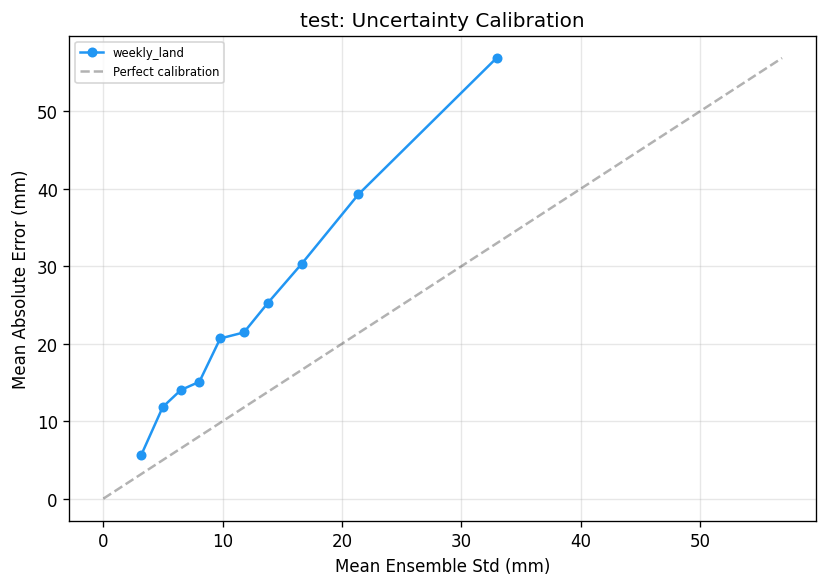

In [15]:
# Uncertainty calibration: binned error vs uncertainty
fig, axes = plt.subplots(1, max(len(eval_splits), 1), figsize=(7 * max(len(eval_splits), 1), 5),
                         squeeze=False)

for si, split in enumerate(eval_splits):
    ax = axes[0, si]
    for ri, name in enumerate(runs_with_preds):
        preds = runs[name]['predictions'].get(split)
        if preds is None:
            continue
        
        unc = preds.get('uncertainty', np.zeros_like(preds['predicted']))
        abs_errors = np.abs(preds['predicted'] - preds['observed'])
        
        # Bin by uncertainty quantiles
        n_bins = 10
        bin_edges = np.percentile(unc, np.linspace(0, 100, n_bins + 1))
        bin_centers = []
        bin_mean_errors = []
        for b in range(n_bins):
            mask = (unc >= bin_edges[b]) & (unc < bin_edges[b + 1])
            if mask.sum() > 0:
                bin_centers.append(unc[mask].mean())
                bin_mean_errors.append(abs_errors[mask].mean())
        
        color = run_plot_colors[ri % len(run_plot_colors)]
        ax.plot(bin_centers, bin_mean_errors, 'o-', color=color, label=name, ms=5)
    
    # Perfect calibration line
    if bin_centers:
        max_v = max(max(bin_centers), max(bin_mean_errors))
        ax.plot([0, max_v], [0, max_v], 'k--', alpha=0.3, label='Perfect calibration')
    ax.set_xlabel('Mean Ensemble Std (mm)')
    ax.set_ylabel('Mean Absolute Error (mm)')
    ax.set_title(f'{split}: Uncertainty Calibration')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Per-Station Error Analysis

In [16]:
# Per-station metrics for each run/split
from scipy.stats import spearmanr

def per_station_metrics(predictions):
    obs = predictions['observed']
    pred = predictions['predicted']
    station_arr = predictions['stations'].astype(str)
    unique = np.unique(station_arr)
    results = {}
    for s in unique:
        mask = station_arr == s
        o, p = obs[mask], pred[mask]
        error = p - o
        rho, _ = spearmanr(o, p) if len(o) > 3 else (float('nan'), 1.0)
        ss_res = np.sum((o - p) ** 2)
        ss_tot = np.sum((o - o.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')
        results[s] = {
            'n': int(mask.sum()),
            'mae': float(np.mean(np.abs(error))),
            'rmse': float(np.sqrt(np.mean(error ** 2))),
            'bias': float(np.mean(error)),
            'r2': float(r2),
            'spearman_r': float(rho),
        }
    return results

# Compute and display
for name in runs_with_preds:
    for split in eval_splits:
        preds = runs[name]['predictions'].get(split)
        if preds is None:
            continue
        station_metrics = per_station_metrics(preds)
        print(f'\n=== {name} / {split} ===')
        print(f'{"Station":<20} {"N":>6} {"MAE":>8} {"RMSE":>8} {"Bias":>8} {"R2":>8} {"Spearman":>8}')
        print('-' * 70)
        for s, m in sorted(station_metrics.items()):
            print(f'{s:<20} {m["n"]:>6} {m["mae"]:>8.1f} {m["rmse"]:>8.1f} {m["bias"]:>8.1f} {m["r2"]:>8.3f} {m["spearman_r"]:>8.3f}')


=== weekly_land / test ===
Station                   N      MAE     RMSE     Bias       R2 Spearman
----------------------------------------------------------------------
aua                     149     39.9     56.9    -30.0    0.474    0.788
masefau                  73     13.3     18.8      9.4    0.872    0.951
siufaga_WRCC            568     21.3     32.8      4.0    0.706    0.878


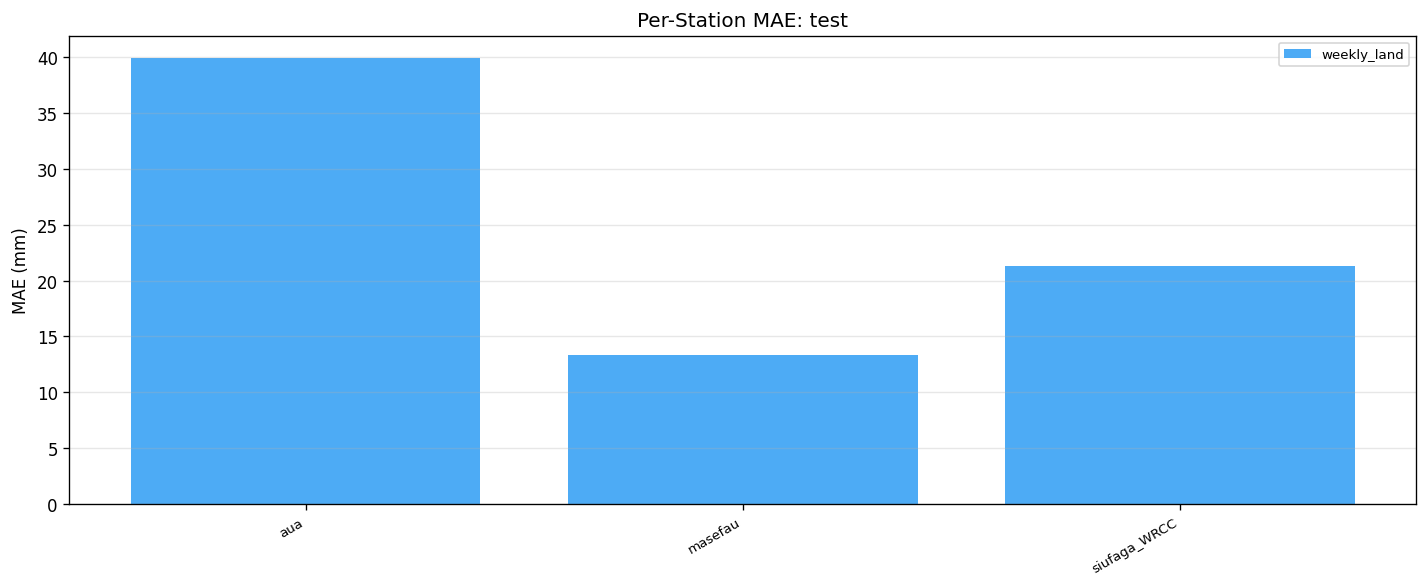

In [17]:
# Per-station MAE comparison across runs (bar chart)
for split in eval_splits:
    all_station_maes = {}
    for name in runs_with_preds:
        preds = runs[name]['predictions'].get(split)
        if preds is None:
            continue
        sm = per_station_metrics(preds)
        all_station_maes[name] = sm
    
    if not all_station_maes:
        continue
    
    all_stations = sorted(set().union(*[set(sm.keys()) for sm in all_station_maes.values()]))
    
    fig, ax = plt.subplots(figsize=(max(10, 4 * len(all_stations)), 5))
    width = 0.8 / len(all_station_maes)
    
    for ri, (name, sm) in enumerate(all_station_maes.items()):
        maes = [sm.get(s, {}).get('mae', 0) for s in all_stations]
        offset = (ri - len(all_station_maes) / 2 + 0.5) * width
        ax.bar(np.arange(len(all_stations)) + offset, maes, width,
               color=run_plot_colors[ri % len(run_plot_colors)], alpha=0.8, label=name)
    
    ax.set_xticks(range(len(all_stations)))
    ax.set_xticklabels(all_stations, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('MAE (mm)')
    ax.set_title(f'Per-Station MAE: {split}')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## 8. Q-Q Plots

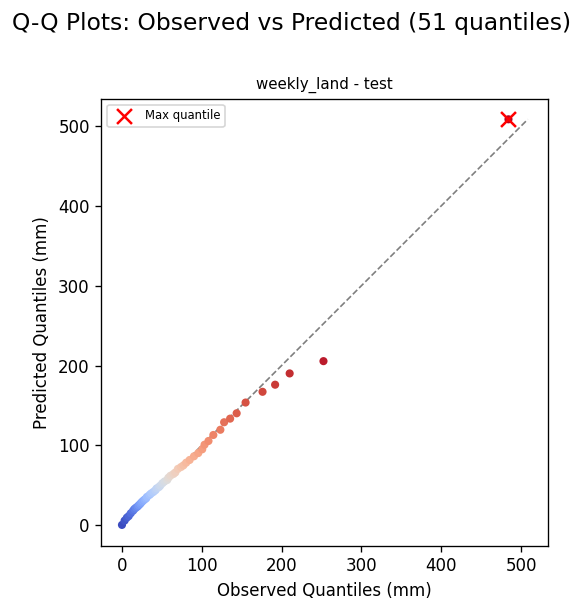

In [18]:
# Q-Q plots: observed vs predicted quantiles
n_quantiles = 51
quantile_probs = np.linspace(0, 1, n_quantiles)

fig, axes = plt.subplots(len(eval_splits), len(runs_with_preds),
                         figsize=(5 * len(runs_with_preds), 5 * max(len(eval_splits), 1)),
                         squeeze=False)

for si, split in enumerate(eval_splits):
    for ri, name in enumerate(runs_with_preds):
        ax = axes[si, ri]
        preds = runs[name]['predictions'].get(split)
        if preds is None:
            continue
        
        obs_q = np.quantile(preds['observed'], quantile_probs)
        pred_q = np.quantile(preds['predicted'], quantile_probs)
        
        ax.scatter(obs_q, pred_q, s=15, c=quantile_probs, cmap='coolwarm', zorder=5)
        ax.scatter(obs_q[-1], pred_q[-1], s=80, marker='x', c='red', zorder=6, label='Max quantile')
        max_val = max(obs_q.max(), pred_q.max())
        ax.plot([0, max_val], [0, max_val], 'k--', lw=1, alpha=0.5)
        ax.set_xlabel('Observed Quantiles (mm)')
        ax.set_ylabel('Predicted Quantiles (mm)')
        ax.set_title(f'{name} - {split}', fontsize=9)
        ax.legend(fontsize=7)
        ax.set_aspect('equal', adjustable='box')

plt.suptitle('Q-Q Plots: Observed vs Predicted (51 quantiles)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Best run: weekly_land on test (MAE=24.1)


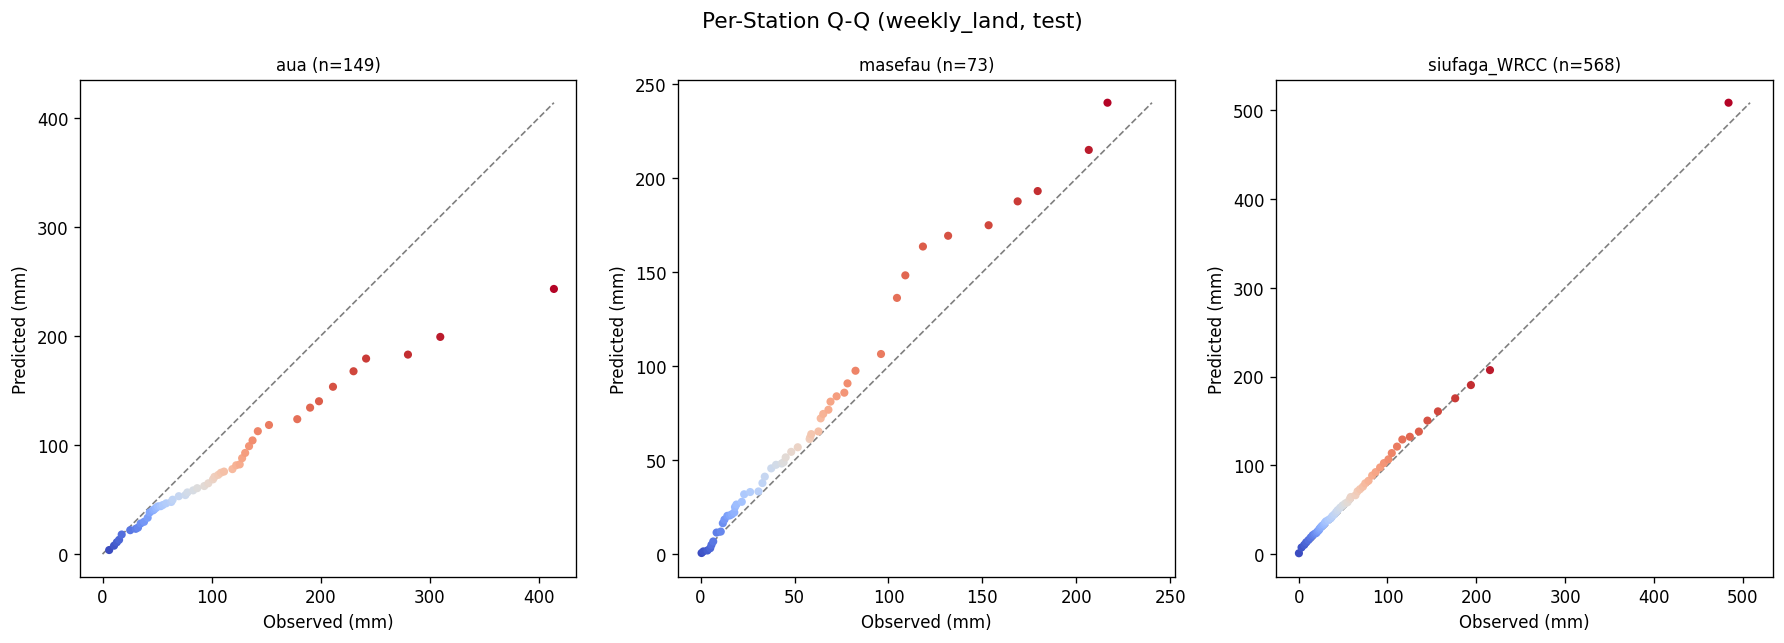

In [19]:
# Per-station Q-Q for the best run (test split)
# Find the best run by test MAE across available eval splits
best_split = None
best_run_name = None
best_mae = float('inf')
for split in eval_splits:
    for n in runs_with_preds:
        if split in runs[n]['eval']:
            mae = runs[n]['eval'][split]['mae']
            if mae < best_mae:
                best_mae = mae
                best_run_name = n
                best_split = split

if best_run_name and best_split:
    print(f'Best run: {best_run_name} on {best_split} (MAE={best_mae:.1f})')
    preds = runs[best_run_name]['predictions'].get(best_split)
    if preds is not None:
        station_arr = preds['stations'].astype(str)
        unique_test_stations = np.unique(station_arr)
        n_test_st = len(unique_test_stations)
        
        fig, axes = plt.subplots(1, n_test_st, figsize=(5 * n_test_st, 5), squeeze=False)
        
        for i, s in enumerate(unique_test_stations):
            mask = station_arr == s
            obs_q = np.quantile(preds['observed'][mask], quantile_probs)
            pred_q = np.quantile(preds['predicted'][mask], quantile_probs)
            
            axes[0, i].scatter(obs_q, pred_q, s=15, c=quantile_probs, cmap='coolwarm', zorder=5)
            max_val = max(obs_q.max(), pred_q.max())
            axes[0, i].plot([0, max_val], [0, max_val], 'k--', lw=1, alpha=0.5)
            axes[0, i].set_xlabel('Observed (mm)')
            axes[0, i].set_ylabel('Predicted (mm)')
            axes[0, i].set_title(f'{s} (n={mask.sum()})', fontsize=10)
            axes[0, i].set_aspect('equal', adjustable='box')
        
        plt.suptitle(f'Per-Station Q-Q ({best_run_name}, {best_split})', fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()
else:
    print('No evaluation data available for Q-Q analysis.')

---
## 9. Temporal Error Patterns

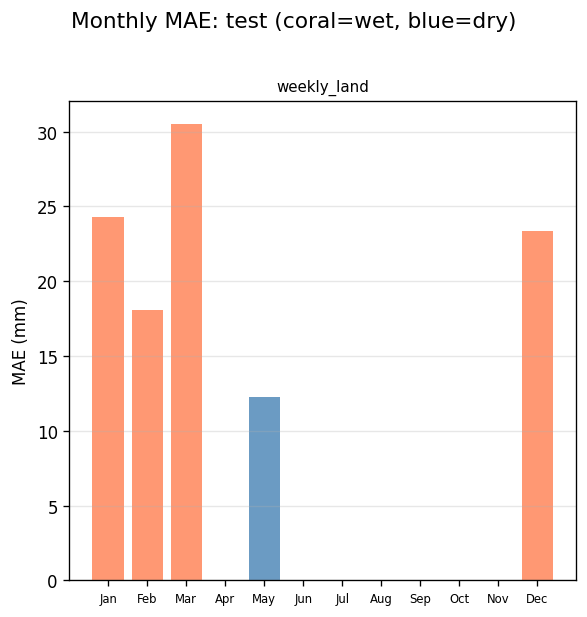

In [20]:
# Seasonal error breakdown for each run
for split in eval_splits:
    runs_with_split = [n for n in runs_with_preds if split in runs[n]['predictions']]
    if not runs_with_split:
        continue
    
    fig, axes = plt.subplots(1, len(runs_with_split), figsize=(5 * len(runs_with_split), 5),
                             squeeze=False)
    
    for ri, name in enumerate(runs_with_split):
        preds = runs[name]['predictions'][split]
        
        # Load dataset to get months for the prediction indices
        ds = np.load(DATASET_PATH, allow_pickle=True)
        all_stations = ds['stations'].astype(str)
        all_years = ds['years'].astype(int)
        all_months = ds['months'].astype(int)
        
        # Match predictions back to months by station+year alignment
        pred_stations = preds['stations'].astype(str)
        pred_years = preds['years'].astype(int)
        
        # Build month array for predictions
        pred_months = np.zeros(len(pred_stations), dtype=int)
        for idx in range(len(pred_stations)):
            mask = (all_stations == pred_stations[idx]) & (all_years == pred_years[idx])
            matches = np.where(mask)[0]
            if len(matches) > 0:
                pred_months[idx] = all_months[matches[0]]
        
        obs = preds['observed']
        pred_vals = preds['predicted']
        abs_errors = np.abs(pred_vals - obs)
        
        # Monthly MAE
        month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
        monthly_mae = []
        for m in range(1, 13):
            mask = pred_months == m
            monthly_mae.append(abs_errors[mask].mean() if mask.sum() > 0 else 0)
        
        wet_months_idx = [10, 11, 0, 1, 2, 3]
        colors = ['coral' if i in wet_months_idx else 'steelblue' for i in range(12)]
        axes[0, ri].bar(range(12), monthly_mae, color=colors, alpha=0.8)
        axes[0, ri].set_xticks(range(12))
        axes[0, ri].set_xticklabels(month_names, fontsize=7)
        axes[0, ri].set_ylabel('MAE (mm)')
        axes[0, ri].set_title(f'{name}', fontsize=9)
        axes[0, ri].grid(axis='y', alpha=0.3)
    
    plt.suptitle(f'Monthly MAE: {split} (coral=wet, blue=dry)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

---
## 10. Residual Analysis

AttributeError: 'Axes' object has no attribute 'reshape'

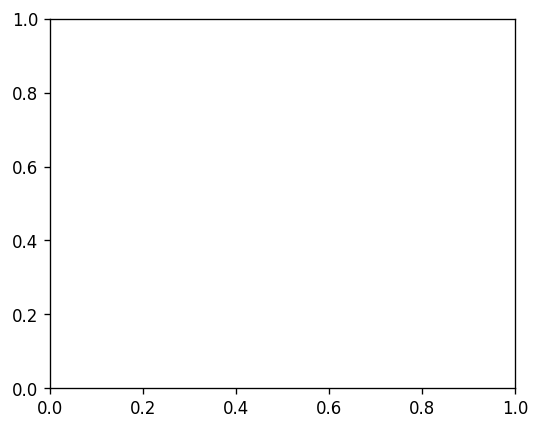

In [21]:
# Residuals vs predicted value (heteroscedasticity check)
fig, axes = plt.subplots(len(eval_splits), len(runs_with_preds),
                         figsize=(5 * len(runs_with_preds), 4 * len(eval_splits)))
if len(runs_with_preds) == 1:
    axes = axes.reshape(-1, 1)
if len(eval_splits) == 1:
    axes = axes.reshape(1, -1)

for si, split in enumerate(eval_splits):
    for ri, name in enumerate(runs_with_preds):
        ax = axes[si, ri]
        preds = runs[name]['predictions'].get(split)
        if preds is None:
            continue
        
        residuals = preds['predicted'] - preds['observed']
        ax.scatter(preds['predicted'], residuals, s=5, alpha=0.3, color='steelblue')
        ax.axhline(0, color='red', ls='--', lw=1)
        
        # Running mean of residuals
        sort_idx = np.argsort(preds['predicted'])
        sorted_pred = preds['predicted'][sort_idx]
        sorted_resid = residuals[sort_idx]
        window = max(len(sorted_resid) // 20, 10)
        if len(sorted_resid) > window:
            running_mean = np.convolve(sorted_resid, np.ones(window)/window, mode='valid')
            ax.plot(sorted_pred[window//2:window//2+len(running_mean)], running_mean,
                    'orange', lw=2, label='Running mean')
        
        ax.set_xlabel('Predicted (mm)')
        ax.set_ylabel('Residual (mm)')
        ax.set_title(f'{name} - {split}', fontsize=9)
        ax.legend(fontsize=7)

plt.suptitle('Residuals vs Predicted (heteroscedasticity check)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

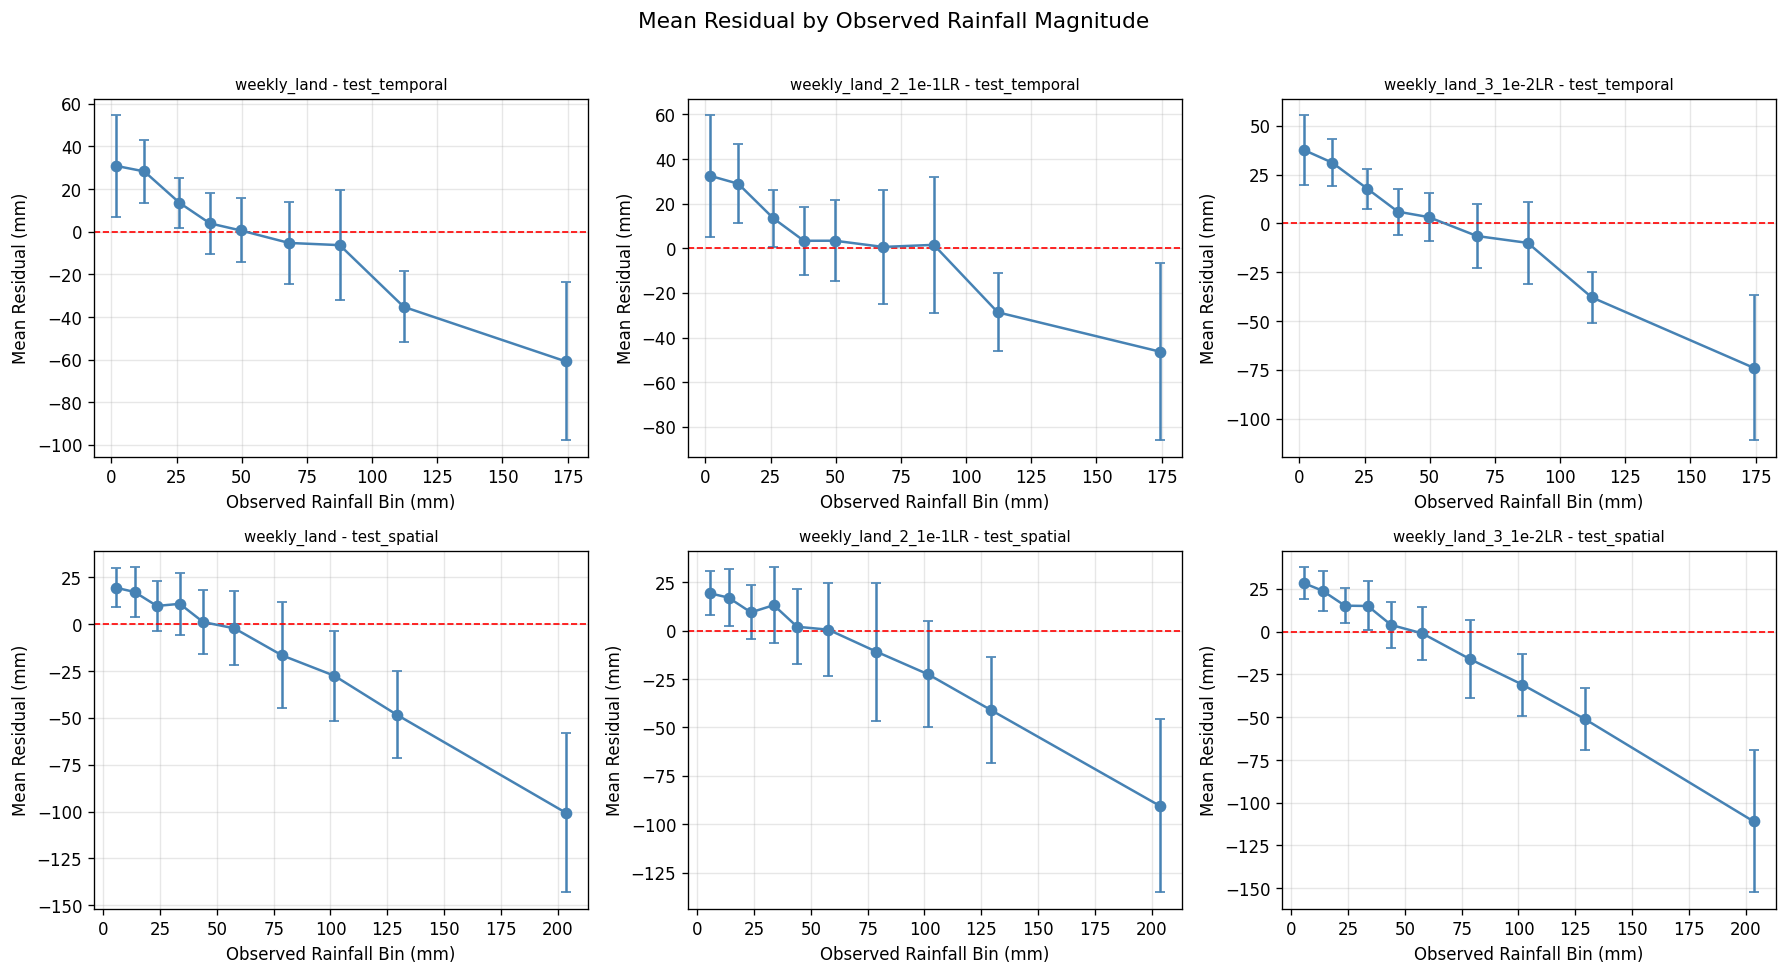

In [ ]:
# Residuals vs observed (bias by rainfall magnitude)
fig, axes = plt.subplots(len(eval_splits), len(runs_with_preds),
                         figsize=(5 * len(runs_with_preds), 4 * len(eval_splits)))
if len(runs_with_preds) == 1:
    axes = axes.reshape(-1, 1)
if len(eval_splits) == 1:
    axes = axes.reshape(1, -1)

for si, split in enumerate(eval_splits):
    for ri, name in enumerate(runs_with_preds):
        ax = axes[si, ri]
        preds = runs[name]['predictions'].get(split)
        if preds is None:
            continue
        
        obs = preds['observed']
        residuals = preds['predicted'] - obs
        
        # Bin by observed value
        n_bins = 10
        bins = np.percentile(obs, np.linspace(0, 100, n_bins + 1))
        bin_centers = []
        bin_mean_res = []
        bin_std_res = []
        for b in range(n_bins):
            mask = (obs >= bins[b]) & (obs < bins[b + 1])
            if mask.sum() > 0:
                bin_centers.append(obs[mask].mean())
                bin_mean_res.append(residuals[mask].mean())
                bin_std_res.append(residuals[mask].std())
        
        ax.errorbar(bin_centers, bin_mean_res, yerr=bin_std_res, fmt='o-',
                    color='steelblue', capsize=3)
        ax.axhline(0, color='red', ls='--', lw=1)
        ax.set_xlabel('Observed Rainfall Bin (mm)')
        ax.set_ylabel('Mean Residual (mm)')
        ax.set_title(f'{name} - {split}', fontsize=9)
        ax.grid(alpha=0.3)

plt.suptitle('Mean Residual by Observed Rainfall Magnitude', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 11. Cross-Run Radar Chart

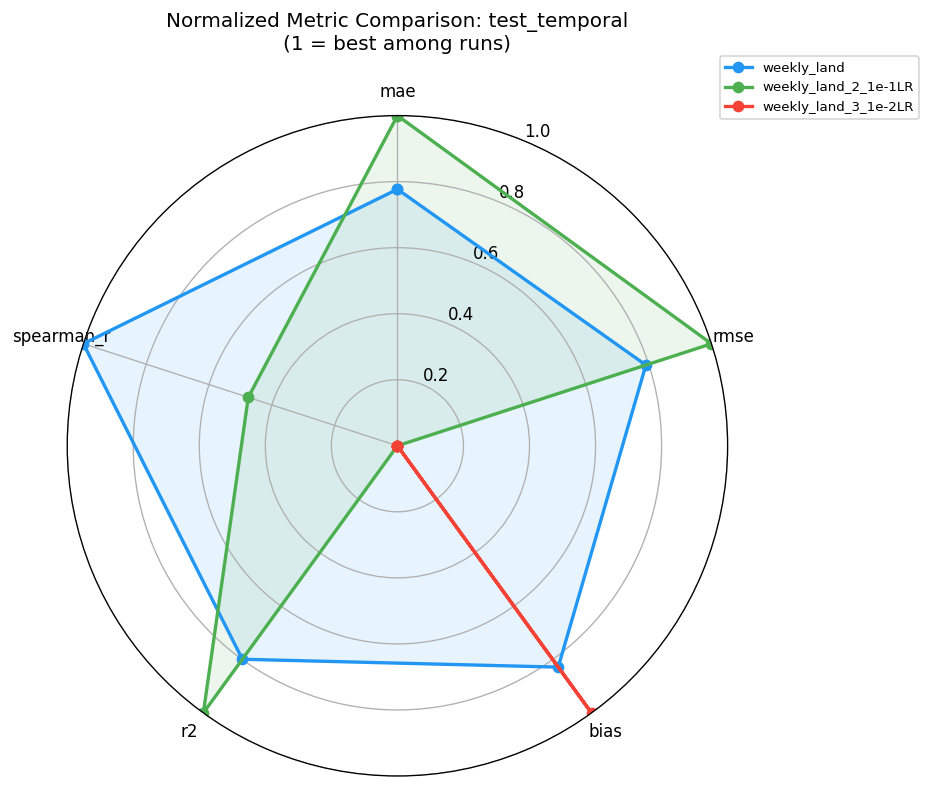

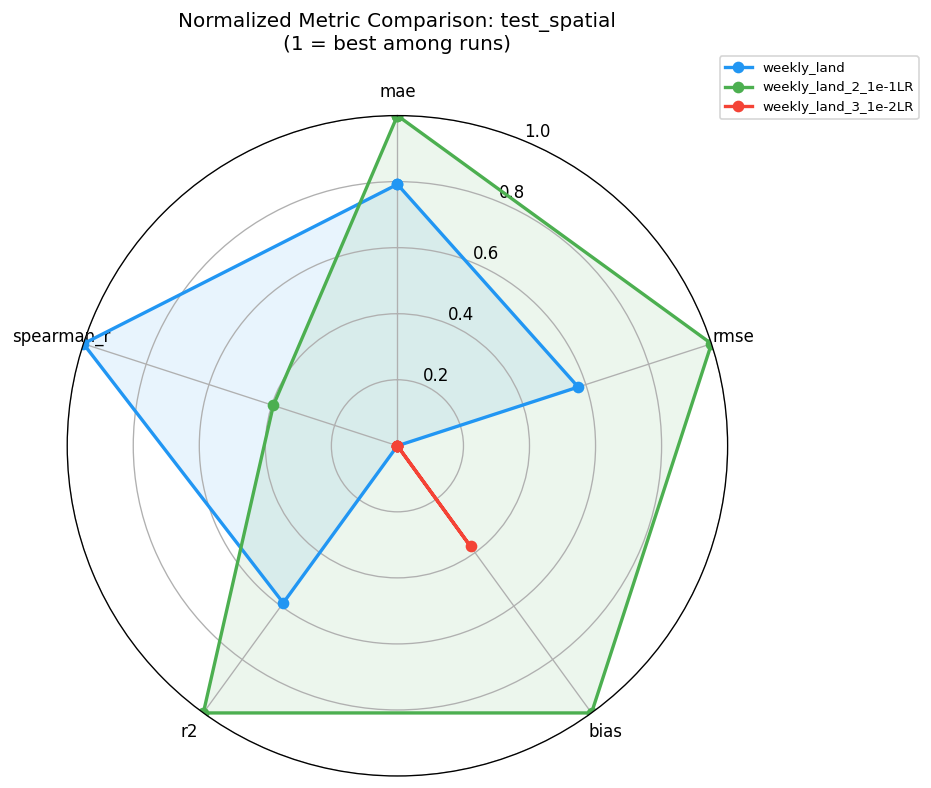

In [ ]:
# Radar chart comparing runs on multiple metrics
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path as MplPath
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine

# Normalized metrics for radar (all in [0,1] where 1 is best)
radar_metrics = ['mae', 'rmse', 'bias', 'r2', 'spearman_r']

for split in eval_splits:
    # Collect values
    run_vals = {}
    for name in run_names:
        if split in eval_data[name]:
            run_vals[name] = eval_data[name][split]
    
    if len(run_vals) < 2:
        continue
    
    # Normalize: for mae/rmse lower is better -> invert; for r2/spearman higher is better
    # for bias: closer to 0 is better -> invert absolute
    all_vals = {m: [run_vals[n][m] for n in run_vals] for m in radar_metrics}
    
    normalized = {}
    for name in run_vals:
        norm_vals = []
        for m in radar_metrics:
            v = run_vals[name][m]
            vals_range = max(all_vals[m]) - min(all_vals[m])
            if vals_range == 0:
                norm_vals.append(0.5)
            elif m in ('mae', 'rmse'):
                norm_vals.append(1 - (v - min(all_vals[m])) / vals_range)
            elif m == 'bias':
                abs_vals = [abs(x) for x in all_vals[m]]
                abs_range = max(abs_vals) - min(abs_vals)
                norm_vals.append(1 - (abs(v) - min(abs_vals)) / abs_range if abs_range > 0 else 0.5)
            else:  # r2, spearman_r
                norm_vals.append((v - min(all_vals[m])) / vals_range)
        normalized[name] = norm_vals
    
    # Plot
    angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_metrics)
    ax.set_ylim(0, 1)
    
    for ri, (name, vals) in enumerate(normalized.items()):
        vals_plot = vals + vals[:1]
        color = run_plot_colors[ri % len(run_plot_colors)]
        ax.plot(angles, vals_plot, 'o-', color=color, lw=2, label=name)
        ax.fill(angles, vals_plot, color=color, alpha=0.1)
    
    ax.set_title(f'Normalized Metric Comparison: {split}\n(1 = best among runs)', fontsize=12, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
    plt.tight_layout()
    plt.show()

---
## 12. Prediction Distribution Comparison

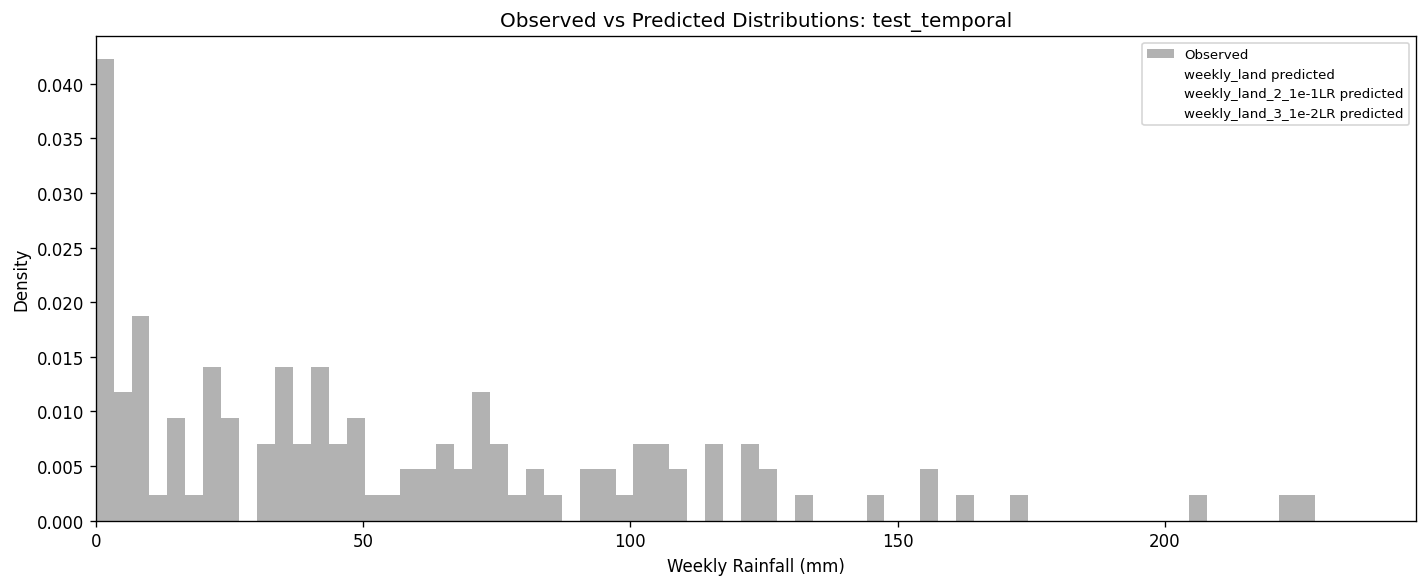

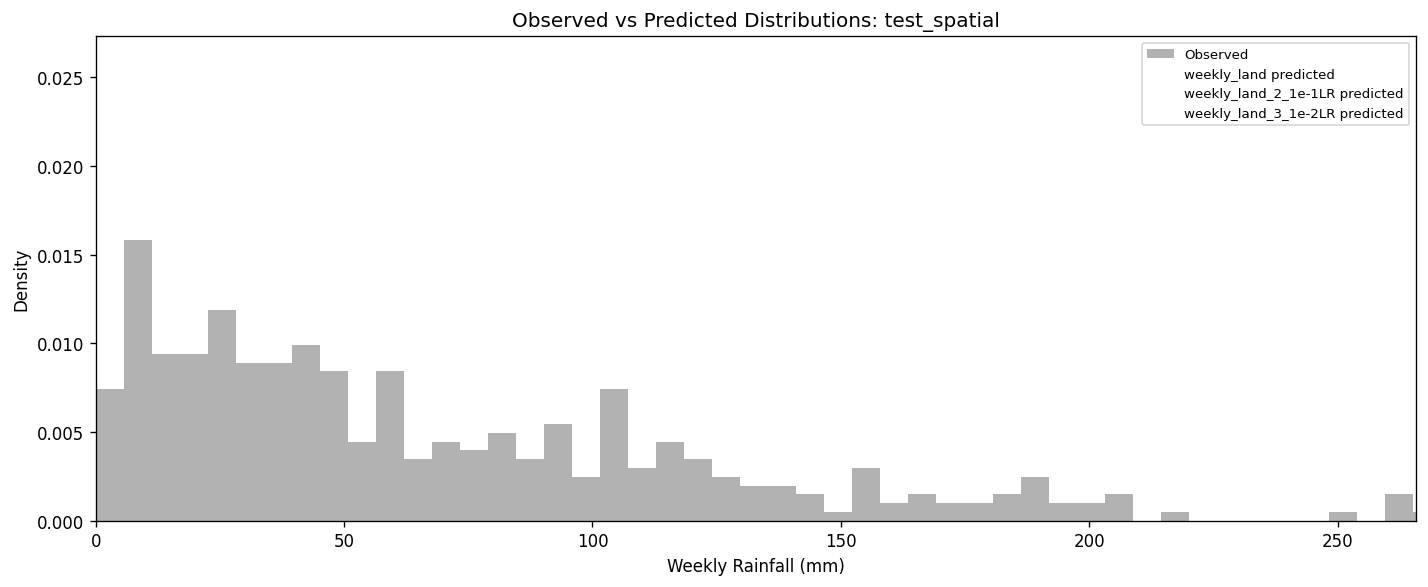

In [ ]:
# Compare predicted distributions across runs against observed
for split in eval_splits:
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Plot observed distribution
    has_obs = False
    for name in runs_with_preds:
        preds = runs[name]['predictions'].get(split)
        if preds is not None and not has_obs:
            ax.hist(preds['observed'], bins=80, alpha=0.3, color='black',
                    label='Observed', density=True, edgecolor='none')
            has_obs = True
    
    # Overlay predicted distributions
    for ri, name in enumerate(runs_with_preds):
        preds = runs[name]['predictions'].get(split)
        if preds is None:
            continue
        color = run_plot_colors[ri % len(run_plot_colors)]
        ax.hist(preds['predicted'], bins=80, alpha=0.4, color=color,
                label=f'{name} predicted', density=True, edgecolor='none', histtype='step', lw=2)
    
    ax.set_xlabel('Weekly Rainfall (mm)')
    ax.set_ylabel('Density')
    ax.set_title(f'Observed vs Predicted Distributions: {split}')
    ax.legend(fontsize=8)
    ax.set_xlim(0, np.percentile(preds['observed'], 99) if preds is not None else 500)
    plt.tight_layout()
    plt.show()

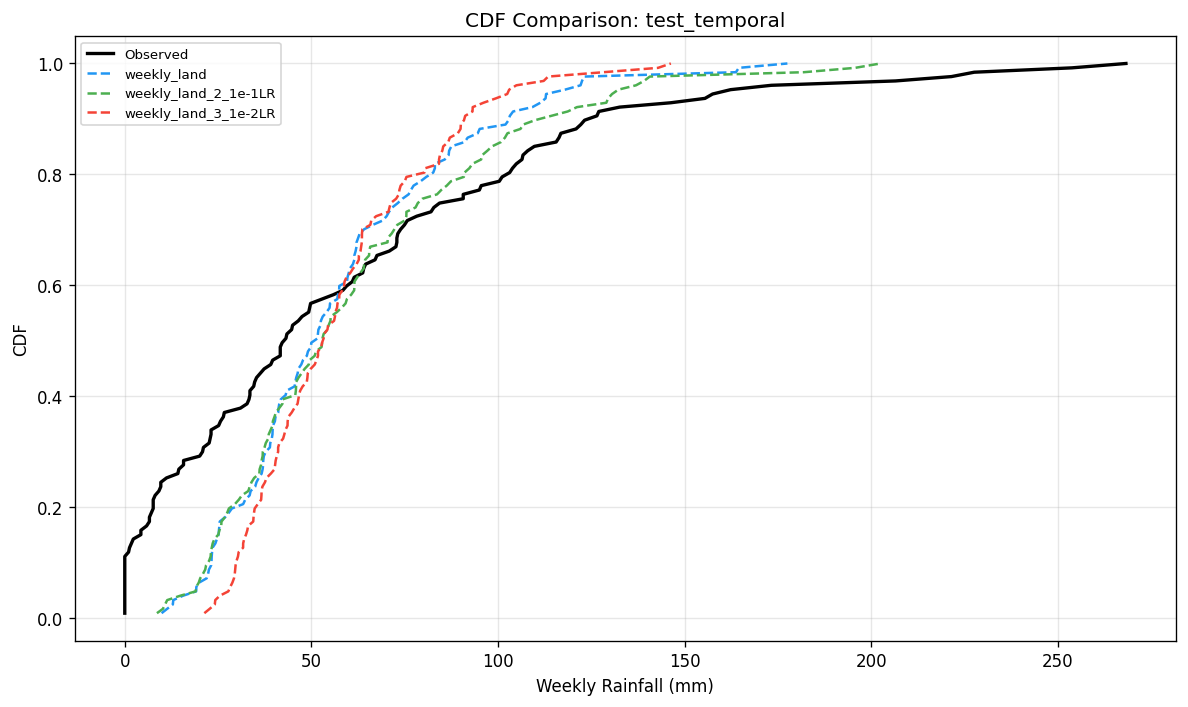

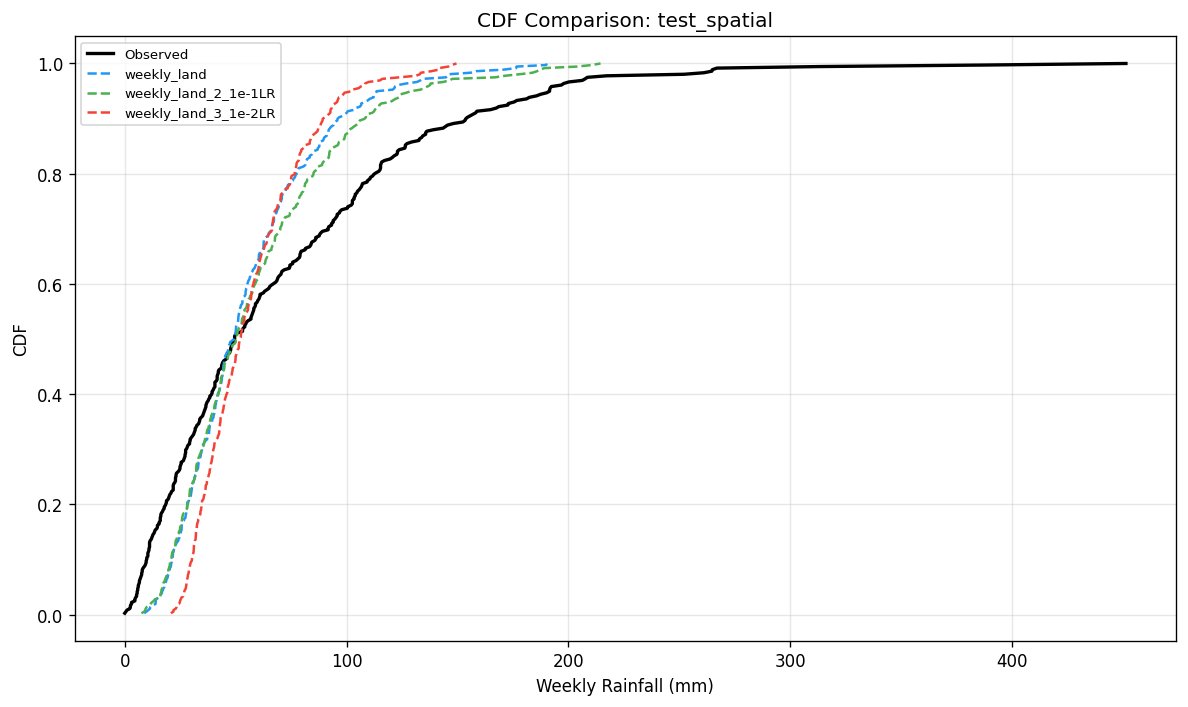

In [ ]:
# CDF comparison
for split in eval_splits:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for name in runs_with_preds:
        preds = runs[name]['predictions'].get(split)
        if preds is None:
            continue
        
        # Observed CDF (same for all runs)
        if name == runs_with_preds[0]:
            sorted_obs = np.sort(preds['observed'])
            cdf_obs = np.arange(1, len(sorted_obs) + 1) / len(sorted_obs)
            ax.plot(sorted_obs, cdf_obs, 'k-', lw=2, label='Observed')
        
        sorted_pred = np.sort(preds['predicted'])
        cdf_pred = np.arange(1, len(sorted_pred) + 1) / len(sorted_pred)
        ri = runs_with_preds.index(name)
        ax.plot(sorted_pred, cdf_pred, '--', color=run_plot_colors[ri % len(run_plot_colors)],
                lw=1.5, label=f'{name}')
    
    ax.set_xlabel('Weekly Rainfall (mm)')
    ax.set_ylabel('CDF')
    ax.set_title(f'CDF Comparison: {split}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## 13. Extreme Rainfall Performance

In [ ]:
# Performance on extreme vs moderate rainfall
for split in eval_splits:
    runs_with_split = [n for n in runs_with_preds if split in runs[n]['predictions']]
    if not runs_with_split:
        continue
    
    fig, axes = plt.subplots(1, len(runs_with_split), figsize=(5 * len(runs_with_split), 5),
                             squeeze=False)
    
    for ri, name in enumerate(runs_with_split):
        preds = runs[name]['predictions'][split]
        obs = preds['observed']
        pred_vals = preds['predicted']
        
        # Define categories
        p50 = np.percentile(obs, 50)
        p90 = np.percentile(obs, 90)
        p95 = np.percentile(obs, 95)
        
        categories = [
            ('Low (<P50)', obs < p50),
            ('Medium (P50-P90)', (obs >= p50) & (obs < p90)),
            ('High (P90-P95)', (obs >= p90) & (obs < p95)),
            ('Extreme (>P95)', obs >= p95),
        ]
        
        cat_names = []
        cat_maes = []
        cat_biases = []
        for cat_name, mask in categories:
            if mask.sum() > 0:
                cat_names.append(cat_name)
                cat_maes.append(np.mean(np.abs(pred_vals[mask] - obs[mask])))
                cat_biases.append(np.mean(pred_vals[mask] - obs[mask]))
        
        x = np.arange(len(cat_names))
        axes[0, ri].bar(x - 0.2, cat_maes, 0.4, color='steelblue', alpha=0.8, label='MAE')
        axes[0, ri].bar(x + 0.2, cat_biases, 0.4, color='coral', alpha=0.8, label='Bias')
        axes[0, ri].axhline(0, color='black', lw=0.5)
        axes[0, ri].set_xticks(x)
        axes[0, ri].set_xticklabels(cat_names, rotation=20, ha='right', fontsize=7)
        axes[0, ri].set_ylabel('mm')
        axes[0, ri].set_title(f'{name}', fontsize=9)
        axes[0, ri].legend(fontsize=7)
        axes[0, ri].grid(axis='y', alpha=0.3)
    
    plt.suptitle(f'MAE & Bias by Rainfall Intensity: {split}', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

---
## Summary

Key findings from training and evaluation:
- Multiple runs explored different hyperparameters (often learning rate ablations)
- Training curves show convergence patterns vary by learning rate and by held-out station
- Final training uses full LOSO CV over the 21 train-pool stations, producing one model per held-out station and seed
- Tuning is performed with a 3-fold spatial CV over the 21 train stations, all within years 1980–2016
- Train and test are strictly spatiotemporally disjoint: 21 stations (1980–2016) vs. 5 stations (2017–2024)
- Evaluation on the 5 held-out test stations gives an unbiased spatial-and-temporal generalization estimate
- Ensemble uncertainty shows some calibration with actual errors
- Model systematically underpredicts at extreme rainfall magnitudes
- Negative bias is prominent in the spatial test (unseen stations)